In [1]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results_dir    = Path("./Compute Machine 5 cores/")
sub_dirs       = ["framework", "notebook"]
platform_names = ["LOCALIZE", "Notebook"]
num_runs       = 5
stages         = ["prepare", "featurize", "split", "gridsearch", "automl"]
stage_names    = ["Prepare", "Featurize", "Split", "Grid-search", "AutoML"]

In [3]:
dfs = {
    "framework": [],
    "notebook" : []
}
offset = 0.0

for sub_dir in sub_dirs:
    for run_num in range(num_runs):
        dfs[sub_dir].append({})
        dict = dfs[sub_dir][run_num]
        for stage in stages:
            p = results_dir / sub_dir / str(run_num+1) / f"{stage}_usage.pkl"
            if not p.exists():
                print(f"missing: {p}")
                continue
        
            df = joblib.load(p)
            print(sub_dir, stage, "\n", df.head())
        
            df["elapsed"] = df["t"] + offset
            offset        = df["elapsed"].iloc[-1]
            df["stage"]   = stage
            
            dict[stage] = df
    
        if not dfs[sub_dir]:
            raise RuntimeError("No usable usage files found.")

framework prepare 
           t  cpu_cores      ram_mb
0  0.000000      0.989  220.933594
1  0.001066      0.000  220.933594
2  0.100550      1.099  198.355469
3  0.201214      0.994  200.859375
4  0.301189      1.000  200.925781
framework featurize 
           t  cpu_cores      ram_mb
0  0.000000      0.988  191.941406
1  0.001035      0.000  191.941406
2  0.100631      1.002  191.941406
3  0.200844      0.994  191.941406
4  0.301325      0.995  192.085938
framework split 
           t  cpu_cores      ram_mb
0  0.000000      0.987  188.000000
1  0.001203      0.000  188.000000
2  0.100819      1.002  188.000000
3  0.200970      0.697  188.171875
4  0.200970      0.988  188.273438
framework gridsearch 
           t  cpu_cores      ram_mb
0  0.000000      0.987  195.363281
1  0.001213      0.000  195.574219
2  0.100957      1.096  283.753906
3  0.201631      0.997  434.480469
4  0.301217      0.905  444.832031
framework automl 
           t  cpu_cores      ram_mb
0  0.000000      0.890 

In [4]:
# Memory statistics table
from statistics import mean
mem_stats  = {sub_dir:{} for sub_dir in sub_dirs}
for stage in stages:
    for sub_dir in sub_dirs:
        df = pd.concat([dfs[sub_dir][run_num][stage]["ram_mb"] for run_num in range(num_runs)])
        mem_max  = df.max()
        mem_q3   = df.quantile(0.75)
        mem_mean = df.mean()
        mem_q1   = df.quantile(0.25)
        mem_min  = df.min()

        mem_stats[sub_dir][stage] = {
            "max"  : mem_max,
            "q3"   : mem_q3,
            "mean" : mem_mean,
            "q1"   : mem_q1,
            "min"  : mem_min
        }

mem_stats_dfs = [pd.DataFrame(mem_stats[sub_dir]) for sub_dir in sub_dirs]
for idx, sub_dir in enumerate(sub_dirs):
    print(sub_dir)
    print(mem_stats_dfs[idx])
    print()

framework
         prepare   featurize       split   gridsearch       automl
max   580.566406  192.113281  188.843750  2596.996094  1240.148438
q3    345.867188  191.851562  188.476562  2430.139648  1129.011719
mean  332.262295  190.198611  187.292721  2309.537780  1077.648424
q1    329.945312  189.105469  185.123047  2322.213867  1012.308594
min   197.109375  185.820312  184.691406   191.382812   194.664062

notebook
         prepare   featurize       split   gridsearch       automl
max   608.660156  275.796875  279.718750  1818.433594  2614.531250
q3    369.605469  268.285156  272.257812  1593.570312  2384.345703
mean  367.093258  266.557813  269.428385  1557.874676  1675.372526
q1    353.851562  265.484375  266.724609  1499.289062  1311.117188
min   259.386719  255.578125  259.277344   276.093750   759.820312



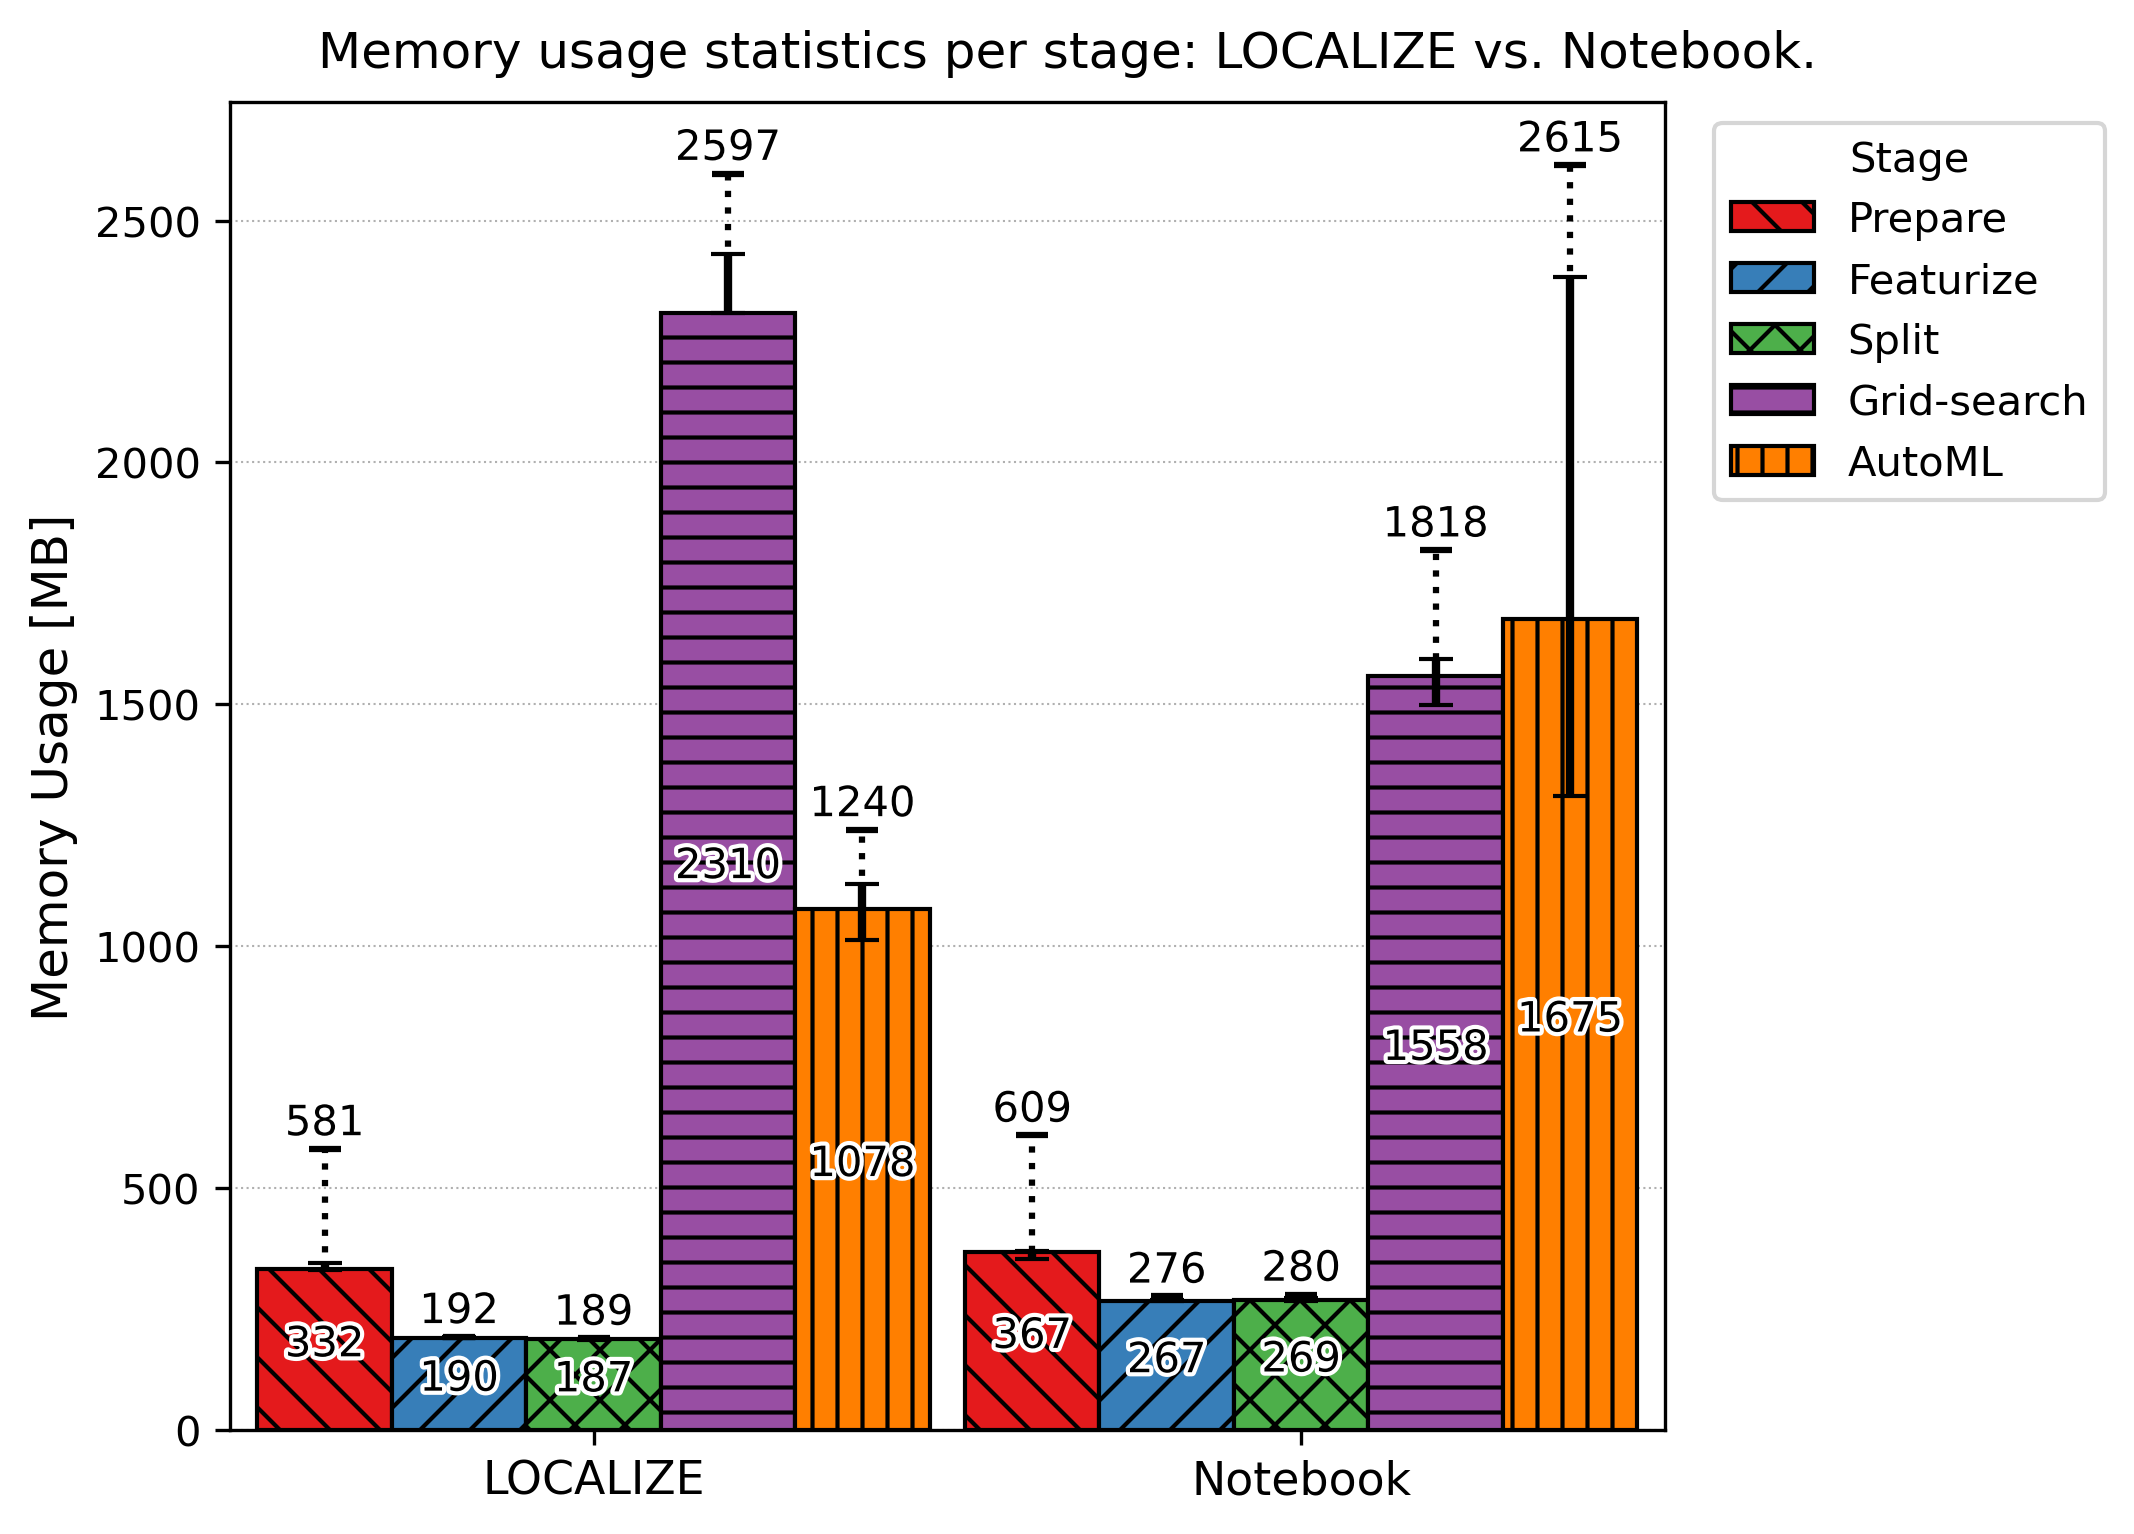

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch 
import matplotlib.colors as mcolors
import colorsys

plt.rc('text', antialiased=True)

def lighten(color, amount):
    """
    Lighten *color* by blending it with white.
    amount = 0   -> original colour
    amount = 1   -> white
    """
    try:
        c = mcolors.to_rgb(color)
    except ValueError:          # named colour
        c = mcolors.to_rgb(mcolors.CSS4_COLORS[color])
    h, l, s = colorsys.rgb_to_hls(*c)
    l = 1 - (1 - l) * (1 - amount)   # push l toward 1
    return colorsys.hls_to_rgb(h, l, s)


# -------- parameters ----------------------------------------------------------
stats   = ['max', 'mean', 'min']
hatches = {'prepare': '\\\\', 'featurize': '//', 'split': 'xx', 'gridsearch':"--", "automl":"||"}
base_cmap = plt.get_cmap("Set1")          
colours   = base_cmap(np.linspace(0, 1, 9)) #base_cmap(np.linspace(0, 1, len(stages)))

#base_cmap = plt.get_cmap("gist_rainbow")        
#colours   = base_cmap(np.linspace(0, 1, len(stages)))

# -------- geometry: how wide each bar is --------------------------------------
n_impl  = len(sub_dirs)    
n_stage = len(stages)
n_stat  = len(stats)

group_width = 0.95
bar_width   = group_width / (n_stage)
alphas      = {'max': 1.0, 'mean': 1.0, 'min': 1.0} 
shade       = {'max': 0.6, 'mean': 0.3, 'min': 0.0}

# -------- create figure -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout = True, dpi=300)

# -------- draw every bar ------------------------------------------------------
for impl_i, (impl_name, df) in enumerate(zip(sub_dirs, mem_stats_dfs)):
    base_x = impl_i
    for stage_i, stage in enumerate(stages):
        x_pos = base_x - group_width/2 + stage_i*bar_width + bar_width/2
        
        m  = df.loc["mean", stage]
        mx = df.loc["max", stage]
        q1 = df.loc["q1", stage]
        q3 = df.loc["q3", stage]

        bar_col = colours[stage_i]

        bar = ax.bar(
            x_pos,
            m,
            width=bar_width,
            color=bar_col,
            hatch=hatches[stage],
            edgecolor='black'
        )
       
        txt = ax.bar_label(bar, padding=1, label_type='center', fmt='%.0f', fontsize=10)
        for t in txt:
            t.set_path_effects([
                pe.Stroke(linewidth=2, foreground='white'),
                pe.Normal()
            ])

        yerr = [[max(m - q1, 0)], [max(q3 - m, 0)]]
        ax.errorbar(x_pos, m, yerr=yerr,
                    fmt='none', ecolor='black', capsize=4, linewidth=2)

        ax.vlines(x_pos, m, mx, linestyles=':', colors='black', linewidth=1.5,
          zorder=3, label="_nolegend_")

        ax.scatter(x_pos, mx, marker='_', s=60, c="black", zorder=4, label="_nolegend_")
        txt = ax.text(x_pos, mx + 10, f"{mx:.0f}", ha='center', va='bottom', fontsize=10, color='black')
        txt.set_path_effects([
            pe.Stroke(linewidth=2, foreground='white'),
            pe.Normal()
        ])

#        for stat in stats:
#            height = df.loc[stat, stage]
#
#            bar_col = lighten(colours[stage_i], shade[stat])
#            ax.bar(
#                x_pos,
#                height,
#                width=bar_width,
#                color=bar_col,
#                edgecolor='black',
#                hatch=hatches[stat],
#                alpha=alphas[stat],
#            )

# -------- x-axis, grid, labels -----------------------------------------------
ax.set_xticks(range(n_impl))
ax.set_xticklabels([platform_names[i] for i, sub_dir in enumerate(sub_dirs)], fontsize=11)
ax.set_ylabel("Memory Usage [MB]", fontsize=12)
ax.margins(x=0.02)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', linewidth=0.5)

# -------- legends -------------------------------------------------------------
# 1 legend for stages (colour)
stage_handles = [
    Patch(facecolor=colours[i], edgecolor='black', label=stage_names[i], hatch=hatches[stage])
    for i, stage in enumerate(stages)
]

## 2 legend for statistics (hatch)
#stat_handles = [
#    Patch(facecolor='white', edgecolor='black', hatch=hatches[s], label=s.capitalize())
#    for s in stats
#]

#first = ax.legend(handles=stat_handles, title="Statistic", loc='upper left', bbox_to_anchor=(1.02, 0.55))
#ax.add_artist(first)   
ax.legend(handles=stage_handles, title="Stage", loc='upper left', bbox_to_anchor=(1.02, 1.0))
fig.suptitle(f"Memory usage statistics per stage: {platform_names[0]} vs. {platform_names[1]}.")

fig.canvas.draw() 

plt.savefig("MemUsageGraph.png", dpi=fig.dpi)
plt.show()  # uncomment to display

In [23]:
for idx, sub_dir in enumerate(sub_dirs):
    df = mem_stats_dfs[idx].copy()
    df.columns = df.columns.str.capitalize()
    df.index = df.index.str.replace("_", " ").str.capitalize()
    
    print(df.to_latex(float_format="%.1f MB"))

\begin{tabular}{lrrrrr}
\toprule
 & Prepare & Featurize & Split & Gridsearch & Automl \\
\midrule
Max & 580.6 MB & 192.1 MB & 188.8 MB & 2597.0 MB & 1240.1 MB \\
Q3 & 345.9 MB & 191.9 MB & 188.5 MB & 2430.1 MB & 1129.0 MB \\
Mean & 332.3 MB & 190.2 MB & 187.3 MB & 2309.5 MB & 1077.6 MB \\
Q1 & 329.9 MB & 189.1 MB & 185.1 MB & 2322.2 MB & 1012.3 MB \\
Min & 197.1 MB & 185.8 MB & 184.7 MB & 191.4 MB & 194.7 MB \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrr}
\toprule
 & Prepare & Featurize & Split & Gridsearch & Automl \\
\midrule
Max & 608.7 MB & 275.8 MB & 279.7 MB & 1818.4 MB & 2614.5 MB \\
Q3 & 369.6 MB & 268.3 MB & 272.3 MB & 1593.6 MB & 2384.3 MB \\
Mean & 367.1 MB & 266.6 MB & 269.4 MB & 1557.9 MB & 1675.4 MB \\
Q1 & 353.9 MB & 265.5 MB & 266.7 MB & 1499.3 MB & 1311.1 MB \\
Min & 259.4 MB & 255.6 MB & 259.3 MB & 276.1 MB & 759.8 MB \\
\bottomrule
\end{tabular}



In [24]:
# CPU statistics table
from statistics import mean
cpu_stats  = {sub_dir:{} for sub_dir in sub_dirs}
for stage in stages:
    for sub_dir in sub_dirs:
        cpu_max  = max ([dfs[sub_dir][run_num][stage]["cpu_cores"].max()  for run_num in range(num_runs)])
        cpu_mean = mean([dfs[sub_dir][run_num][stage]["cpu_cores"].mean() for run_num in range(num_runs)])
        cpu_min  = min ([dfs[sub_dir][run_num][stage]["cpu_cores"].min()  for run_num in range(num_runs)])

        cpu_stats[sub_dir][stage] = {
            f"max"  : cpu_max,
            f"mean" : cpu_mean,
            f"min"  : cpu_min
        }

cpu_stats_dfs = [pd.DataFrame(cpu_stats[sub_dir]) for sub_dir in sub_dirs]
for idx, sub_dir in enumerate(sub_dirs):
    print(sub_dir)
    print(cpu_stats_dfs[idx])
    print()

framework
       prepare  featurize    split  gridsearch    automl
max   6.388000   1.062000  1.08200   34.475000  8.229000
mean  0.987512   0.756467  0.51611    4.671045  1.548394
min   0.000000   0.000000  0.00000    0.000000  0.000000

notebook
      prepare  featurize  split  gridsearch     automl
max   1.41200     0.1980  1.084   20.600000  31.376000
mean  1.00698     0.0787  0.392    4.525663   1.475144
min   0.00000     0.0000  0.000    0.000000   0.000000



In [25]:
# CPU Time
import joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt
cpu_secs = {sub_dir:[] for sub_dir in sub_dirs}
for sub_dir in sub_dirs:
    for run_num in range(num_runs):
        cpu_secs[sub_dir].append({})
        for stage in stages:
            df = dfs[sub_dir][run_num][stage]
            cpu_secs[sub_dir][run_num][stage] = {
                "CPU_time": np.trapz(df["cpu_cores"].values, df["elapsed"].values),
                "wall_time"     : df["t"].iloc[-1]
            }
        cpu_secs[sub_dir][run_num] = pd.DataFrame(cpu_secs[sub_dir][run_num])
    cpu_secs[sub_dir] = pd.concat(cpu_secs[sub_dir]).groupby(level=0).mean()

for idx, sub_dir in enumerate(sub_dirs):
    print(sub_dir)
    print(cpu_secs[sub_dir])
    print()

framework
             prepare  featurize     split   gridsearch       automl
CPU_time   18.465180   0.444804  0.319515  3218.198567  1198.559754
wall_time  18.583213   0.502536  0.466464   687.705529   774.393629

notebook
             prepare  featurize     split   gridsearch       automl
CPU_time   18.744669   0.000089  0.003489  3053.984644  1207.098731
wall_time  18.541166   0.001073  0.040939   675.103705   823.357739



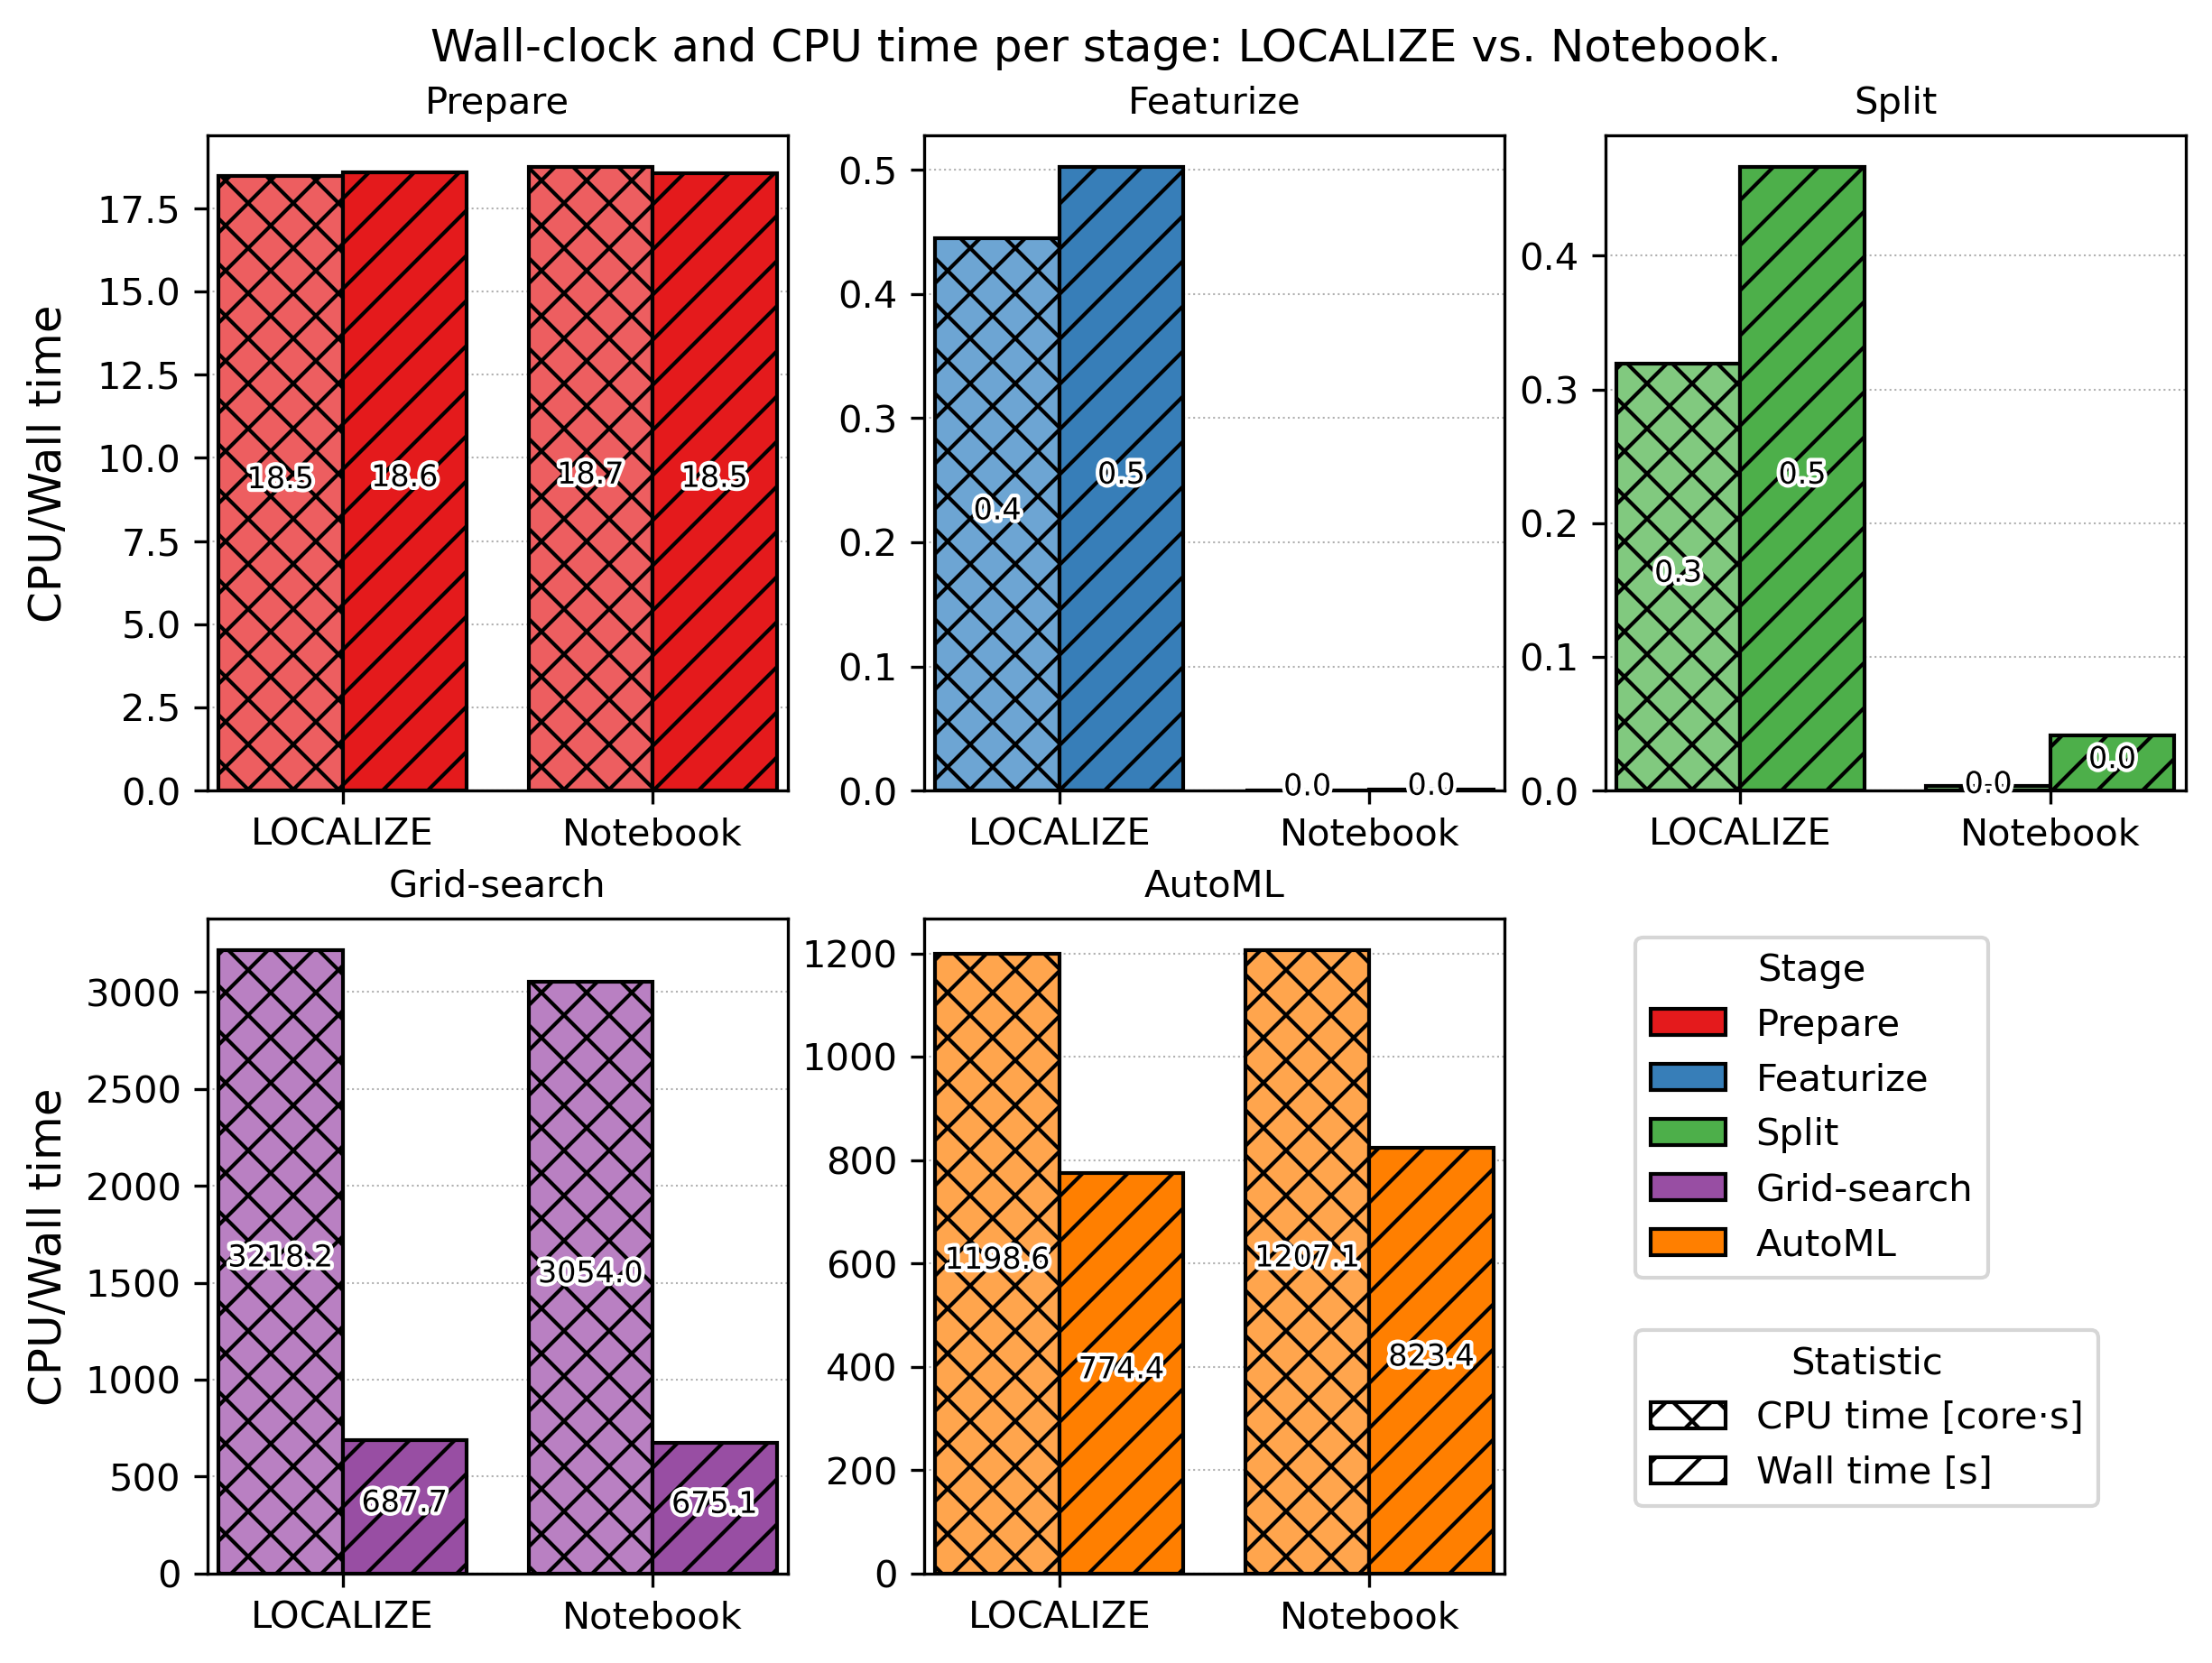

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 
import matplotlib.colors as mcolors
import colorsys

def lighten(color, amount):
    """
    Lighten *color* by blending it with white.
    amount = 0   -> original colour
    amount = 1   -> white
    """
    try:
        c = mcolors.to_rgb(color)
    except ValueError:          # named colour
        c = mcolors.to_rgb(mcolors.CSS4_COLORS[color])
    h, l, s = colorsys.rgb_to_hls(*c)
    l = 1 - (1 - l) * (1 - amount)   # push l toward 1
    return colorsys.hls_to_rgb(h, l, s)


# -------- parameters ----------------------------------------------------------
stats   = ['CPU_time', 'wall_time']
hatches = {'CPU_time': 'xx', 'wall_time': '//'}
base_cmap = plt.get_cmap("Set1")          
colours   = base_cmap(np.linspace(0, 1, 9)) #base_cmap(np.linspace(0, 1, len(stages)))

#base_cmap = plt.get_cmap("gist_rainbow")        
#colours   = base_cmap(np.linspace(0, 1, len(stages)))

# -------- geometry: how wide each bar is --------------------------------------
n_impl  = len(sub_dirs)    
n_stage = len(stages)
n_stat  = len(stats)

group_width = 0.8
bar_width   = group_width / (n_stat)
alphas      = {'CPU_time': 1.0, 'wall_time': 1.0} 
shade       = {'CPU_time': 0.3, 'wall_time': 0.0}


fig, axes = plt.subplots(2, 3, figsize=(8, 6), constrained_layout=True, dpi=300)
axes = axes.flatten()
# -------- draw every bar ------------------------------------------------------
for stage_i, (stage, ax) in enumerate(zip(stages, axes[:-1])):
    # -------- create figure -------------------------------------------------------
    for impl_i, (impl_name, df) in enumerate(zip(sub_dirs, cpu_secs.values())):
        for stat_i, stat in enumerate(stats):
            base_x = impl_i
            #x_pos = base_x - group_width/2 + stage_i*bar_width + bar_width/2
            x_pos = base_x - group_width/2 + stat_i*bar_width + bar_width/2

            height = df.loc[stat, stage]

            bar_col = lighten(colours[stage_i], shade[stat])
            bar = ax.bar(
                x_pos,
                height,
                width=bar_width,
                color=bar_col,
                edgecolor='black',
                hatch=hatches[stat],
                alpha=alphas[stat],
            )
            texts = ax.bar_label(bar, padding=1, label_type='center', fmt='%.1f', fontsize=8)
            for t in texts:
                t.set_path_effects([
                    pe.Stroke(linewidth=2, foreground='white'),  # outline
                    pe.Normal()                                  # fill (uses the current text color)
                ])

    # -------- x-axis, grid, labels -----------------------------------------------
    ax.set_xticks(range(n_impl))
    ax.set_xticklabels([platform_names[i] for i, sub_dir in enumerate(sub_dirs)], fontsize=10)
    ax.margins(x=0.02)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle=':', linewidth=0.5)

# -------- legends -------------------------------------------------------------
ax = axes[-1]
ax.axis("off") 

# 1 legend for stages (colour)
stage_handles = [
    Patch(facecolor=colours[i], edgecolor='black', label=stage_names[i])
    for i, stage in enumerate(stages)
]

units = {"CPU_time": " [core·s]", "wall_time":" [s]"}
stat_display = {"CPU_time": "CPU time", "wall_time":"Wall time"}
# 2 legend for statistics (hatch)
stat_handles = [
    Patch(facecolor='white', edgecolor='black', hatch=hatches[s], label=stat_display[s]+units[s])
    for s in stats
]

first = ax.legend(handles=stage_handles, title="Stage", loc='upper left', bbox_to_anchor=(0.02, 1.0))
ax.add_artist(first)                              # keep first legend when adding second
ax.legend(handles=stat_handles, title="Statistic", loc='upper left', bbox_to_anchor=(0.02, 0.4))

# -------- titles & ylabel -----------------------------------------------------
for stage_i, (ax, stage) in enumerate(zip(axes[:-1], stages)):
    ax.set_title(stage_names[stage_i], fontsize=10)
    if stage_i%3 == 0:
        ax.set_ylabel(f"CPU/Wall time", fontsize=12)

fig.align_ylabels()
fig.set_constrained_layout_pads( 
        w_pad=1/72, h_pad=2/72,
        wspace=0.02, hspace=0.01)

fig.suptitle(f"Wall-clock and CPU time per stage: {platform_names[0]} vs. {platform_names[1]}.")

#fig.subplots_adjust(right=0.8, left=0.08, top=1, bottom=0)
fig.canvas.draw()                          

#bbox = fig.get_tightbbox(fig.canvas.get_renderer())
#new_w, new_h = bbox.width, bbox.height
#
#fig.set_size_inches(new_w, new_h, forward=True) 
plt.savefig("CPUWall_time.png", dpi=fig.dpi) #,bbox_inches="tight", bbox_extra_artists=fig.get_children()
plt.show()

In [29]:
import re

def is_blank(line):
    return line.strip() == ""

def strip_comment(line):
    line = line.split("#", 1)[0]
    line = re.sub(r'("""|\'\'\')(.*?)\1', '', line)
    return line.rstrip()

def strip_structural(line):
    return "".join([token for token in line if token not in "{}[](),"])

def is_meaningful_line(line):
    if is_blank(line):
        return False
    if is_blank(strip_comment(line)):
        return False
    if is_blank(strip_structural(line)):
        return False
    return True

def strip_meaningless(lines):
    return [strip_comment(line) for line in lines if is_meaningful_line(line)]

In [30]:
import json
import os

def extract_code_lines_notebook(ipynb_path):
    """Extracts code lines from a Jupyter notebook (.ipynb) as a list of strings."""
    with open(ipynb_path, 'r', encoding='utf-8') as f:
        notebook = json.load(f)

    lines = []
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") == "code":
            lines.extend(cell.get("source", []))  # source is already a list of lines
            lines.append("\n")  # separate cells with a newline
    return lines

In [31]:
notebooks_path = Path("../JupyterLab/")
notebooks = sorted([Path(file) for file in os.listdir(notebooks_path) if file.endswith(".ipynb")])
notebooks

[PosixPath('00-Initial.ipynb'),
 PosixPath('01-Changed_and_added_model.ipynb'),
 PosixPath('02-Changed_dataset_to_logatec.ipynb'),
 PosixPath('03-Added_split_and_metric.ipynb'),
 PosixPath('04-Added_automl_model.ipynb'),
 PosixPath('Benchmarking.ipynb')]

In [32]:
def keep_unique_lines(lines, other):
    out = []
    other = [line.strip() for line in other]
    for line in lines:
        stripped = line.strip()
        if stripped in other:
            other.remove(stripped)
        else:
            out.append(line)
    return out

In [33]:
def remove_unwanted_lines(lines, notebook):
    return [line for line in lines if notebook.stem not in line]

In [34]:
from rich.console import Console
from rich.syntax import Syntax
from rich.text import Text
import sys

def color_diff_lines(lines, prefix, prefix_style):
    styled = []
    for line in lines:
        # Create a Text object
        text = Text(end = "")
        text.append(f"{prefix} ", style=prefix_style)
        code = line.strip("\n")
        syntax = Syntax(code, "python", theme="monokai", line_numbers=False, word_wrap=False) 
        hlcd = syntax.highlight(code)
        hlcd.rstrip()
        text.append(hlcd)  # only highlight the actual code
        styled.append(text)
    return styled

pr = strip_meaningless(extract_code_lines_notebook(notebooks_path / notebooks[0]))
pr = remove_unwanted_lines(pr, notebooks[0])

chj = {
    "deleted": [],
    "added": []
}

print("Jupyter:")
for notebook in notebooks[1:5]:
    c = strip_meaningless(extract_code_lines_notebook(notebooks_path / notebook))
    c = remove_unwanted_lines(c, notebook)

    deleted = keep_unique_lines(pr, c)
    added   = keep_unique_lines(c, pr)

    deleted_styled = color_diff_lines(deleted, "-", "bold red")
    added_styled   = color_diff_lines(added, "+", "bold green")

    pr = c

    console = Console(
        force_jupyter=False,
        force_terminal=True,
        file=sys.stdout,
    )

    console.print(f"  [bold red]lines deleted:[/] {len(deleted)}")
    console.print(f"  [green]lines added:[/] {len(added)}")
    print("____________________\n")
    chj["deleted"].append(len(deleted))
    chj["added"].append(len(added))

    

Jupyter:
  lines deleted: 4
  lines added: 16
____________________

  lines deleted: 38
  lines added: 55
____________________

  lines deleted: 14
  lines added: 24
____________________

  lines deleted: 3
  lines added: 91
____________________



In [35]:
configs_path = Path("../low-code-localization/configs/")
configs      = sorted([Path(file) for file in os.listdir(configs_path)])[1:6]


In [36]:
def extract_code_lines_yaml(path):
    with open(path, 'r', encoding='utf-8') as f:
        return f.readlines()

In [37]:
def color_diff_lines(lines, prefix, prefix_style):
    styled = []
    for line in lines:
        # Create a Text object
        text = Text(end = "")
        text.append(f"{prefix} ", style=prefix_style)
        code = line.strip("\n")
        syntax = Syntax(code, "yaml", theme="monokai", line_numbers=False, word_wrap=False) 
        hlcd = syntax.highlight(code)
        hlcd.rstrip()
        text.append(hlcd)  # only highlight the actual code
        styled.append(text)
    return styled
    
print("Framework:")
chf = {
    "dvc.yaml":{
        "deleted": [],
        "added": []
    },
    "params.yaml":{
        "deleted": [],
        "added": []
    }
}
for cnf in ["dvc.yaml", "params.yaml"]:
    pr = strip_meaningless(extract_code_lines_yaml(configs_path / configs[0] / cnf))
    pr = remove_unwanted_lines(pr, configs[0])
    for config in configs[1:]:
        print(cnf)
        c = strip_meaningless(extract_code_lines_yaml(configs_path / config / cnf))
        c = remove_unwanted_lines(c, config)
    
        deleted = keep_unique_lines(pr, c)
        added   = keep_unique_lines(c, pr)
    
        deleted_styled = color_diff_lines(deleted, "-", "bold red")
        added_styled   = color_diff_lines(added, "+", "bold green")
    
        pr = c
    
        console = Console(
            force_jupyter=False,
            force_terminal=True,
            file=sys.stdout,
            width = 120
        )
    
        console.print(f"  [bold red]lines deleted:[/] {len(deleted)}")
        console.print(f"  [green]lines added:[/] {len(added)}")

        #for line in deleted_styled:
        #    console.print(line)
        #console.print("\n")
        #
        #for line in added_styled:
        #    console.print(line)
        #console.print("\n[dim]" + "_" * 110 + "[/]\n")

        chf[cnf]["deleted"].append(len(deleted))
        chf[cnf]["added"].append(len(added))

    print("____________________\n")

Framework:
dvc.yaml
  lines deleted: 0
  lines added: 0
dvc.yaml
  lines deleted: 27
  lines added: 29
dvc.yaml
  lines deleted: 0
  lines added: 0
dvc.yaml
  lines deleted: 0
  lines added: 21
____________________

params.yaml
  lines deleted: 4
  lines added: 16
params.yaml
  lines deleted: 0
  lines added: 0
params.yaml
  lines deleted: 2
  lines added: 2
params.yaml
  lines deleted: 0
  lines added: 16
____________________



In [38]:
chf

{'dvc.yaml': {'deleted': [0, 27, 0, 0], 'added': [0, 29, 0, 21]},
 'params.yaml': {'deleted': [4, 0, 2, 0], 'added': [16, 0, 2, 16]}}

In [39]:
chj

{'deleted': [4, 38, 14, 3], 'added': [16, 55, 24, 91]}

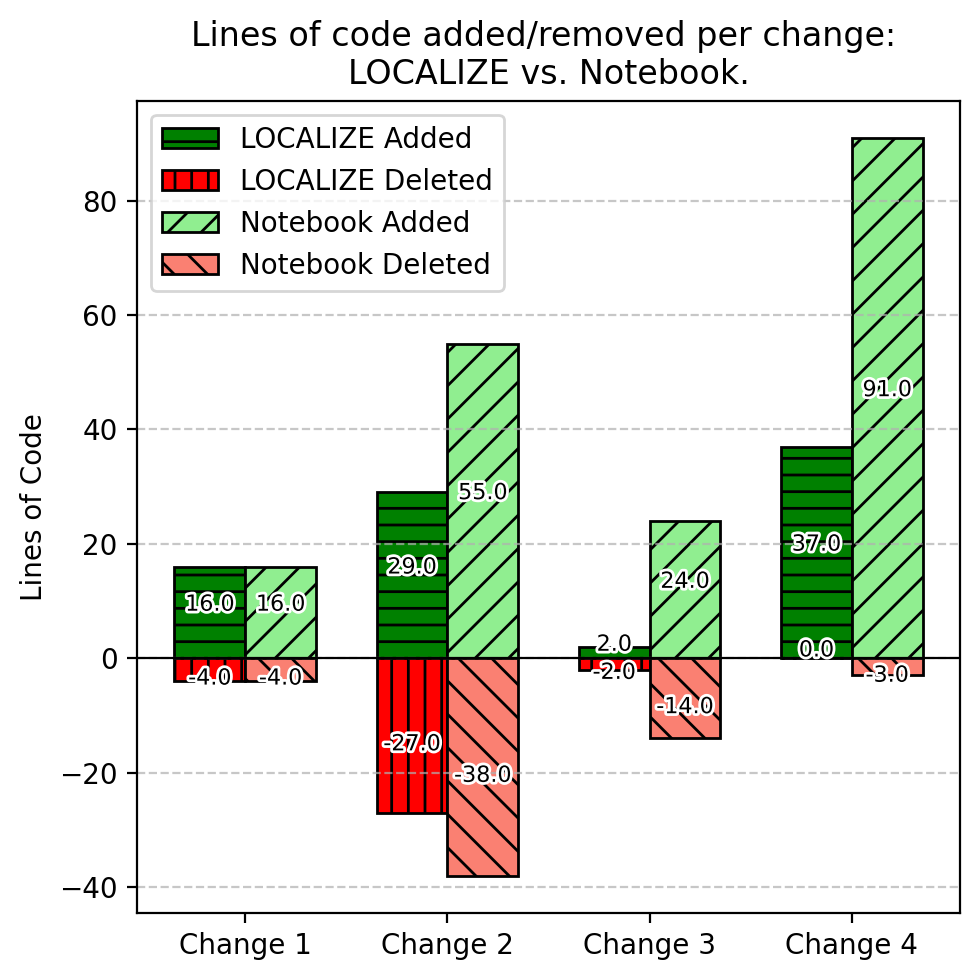

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the image
framework = chf

jupyter = chj

# Sum added and deleted across all files in framework1
framework_deleted = np.sum([framework[file]['deleted'] for file in framework], axis=0)
framework_added = np.sum([framework[file]['added'] for file in framework], axis=0)

# Prepare plot
x = np.arange(4)
width = 0.35

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)

# Plotting
bar = ax.bar(x - width/2, framework_added, width, label=f'{platform_names[0]} Added', color='green', hatch="--", edgecolor="black")
texts = ax.bar_label(bar, padding=3, label_type='center', fmt='%.1f', fontsize=8)
for t in texts:
    t.set_path_effects([
        pe.Stroke(linewidth=2, foreground='white'),  # outline
        pe.Normal()                                  # fill (uses the current text color)
    ])
bar = ax.bar(x - width/2, -framework_deleted, width, label=f'{platform_names[0]} Deleted', color='red', hatch="||", edgecolor="black")
texts = ax.bar_label(bar, padding=3, label_type='center', fmt='%.1f', fontsize=8)
for t in texts:
    t.set_path_effects([
        pe.Stroke(linewidth=2, foreground='white'),  # outline
        pe.Normal()                                  # fill (uses the current text color)
    ])

bar = ax.bar(x + width/2, jupyter['added'], width, label=f'{platform_names[1]} Added', color='lightgreen', hatch="//", edgecolor="black")
texts = ax.bar_label(bar, padding=3, label_type='center', fmt='%.1f', fontsize=8)
for t in texts:
    t.set_path_effects([
        pe.Stroke(linewidth=2, foreground='white'),  # outline
        pe.Normal()                                  # fill (uses the current text color)
    ])
bar = ax.bar(x + width/2, -np.array(jupyter['deleted']), width, label=f'{platform_names[1]} Deleted', color='salmon', hatch="\\\\", edgecolor="black")

texts = ax.bar_label(bar, padding=3, label_type='center', fmt='%.1f', fontsize=8)
for t in texts:
    t.set_path_effects([
        pe.Stroke(linewidth=2, foreground='white'),  # outline
        pe.Normal()                                  # fill (uses the current text color)
    ])

# Customizations
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Lines of Code")
ax.set_title(f"Lines of code added/removed per change: \n{platform_names[0]} vs. {platform_names[1]}.")
ax.set_xticks(x)
ax.set_xticklabels([f'Change {i+1}' for i in x])
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig("LOCchanged.png")

In [41]:
dir_path = Path("./dataset_size/")
sub_dirs = ["1x", "5x", "10x"]
stages   = ["prepare", "featurize", "split", "gridsearch", "automl"]

In [42]:
dfs = {}
offset = 0.0

for sub_dir in sub_dirs:
    dfs[sub_dir] = {} 
    dict = dfs[sub_dir]
    for stage in stages:
        p = dir_path / sub_dir / f"{stage}_usage.pkl"
        if not p.exists():
            print(f"missing: {p}")
            continue
    
        df = joblib.load(p)
        #print(sub_dir, stage, "\n", df.head())
    
        df["elapsed"] = df["t"] + offset
        offset        = df["elapsed"].iloc[-1]
        df["stage"]   = stage
        
        dict[stage] = df

    if not dfs[sub_dir]:
        raise RuntimeError("No usable usage files found.")

In [43]:
# Memory statistics table
from statistics import mean
mem_stats  = {sub_dir:{} for sub_dir in sub_dirs}
for stage in stages:
    for sub_dir in sub_dirs:
        df = dfs[sub_dir][stage]["ram_mb"]
        mem_max  = df.max()
        mem_q3   = df.quantile(0.75)
        mem_mean = df.mean()
        mem_q1   = df.quantile(0.25)
        mem_min  = df.min()

        mem_stats[sub_dir][stage] = {
            "max"  : mem_max,
            "q3"   : mem_q3,
            "mean" : mem_mean,
            "q1"   : mem_q1,
            "min"  : mem_min
        }

mem_stats_dfs = [pd.DataFrame(mem_stats[sub_dir]) for sub_dir in sub_dirs]
for idx, sub_dir in enumerate(sub_dirs):
    print(sub_dir)
    print(mem_stats_dfs[idx])
    print()

1x
         prepare   featurize       split   gridsearch       automl
max   580.125000  192.113281  188.523438  2552.582031  1240.019531
q3    348.855469  191.941406  188.273438  2431.605469  1128.738281
mean  336.580354  190.322917  187.125000  2313.039509  1077.083840
q1    329.945312  189.300781  185.031250  2325.705078  1011.996094
min   198.355469  185.820312  184.960938   194.371094   196.359375

5x
         prepare   featurize       split   gridsearch       automl
max   579.542969  216.609375  196.152344  3040.554688  1216.691406
q3    350.031250  216.232422  195.636719  2774.843750  1142.992188
mean  334.252714  212.990675  193.695524  2607.679928  1094.505921
q1    334.789062  215.468750  194.742188  2398.160156  1048.714844
min   198.195312  189.500000  185.296875   194.007812   195.089844

10x
         prepare   featurize       split   gridsearch       automl
max   579.820312  247.257812  205.449219  3274.992188  1216.691406
q3    352.800781  246.582031  205.449219  3065.517

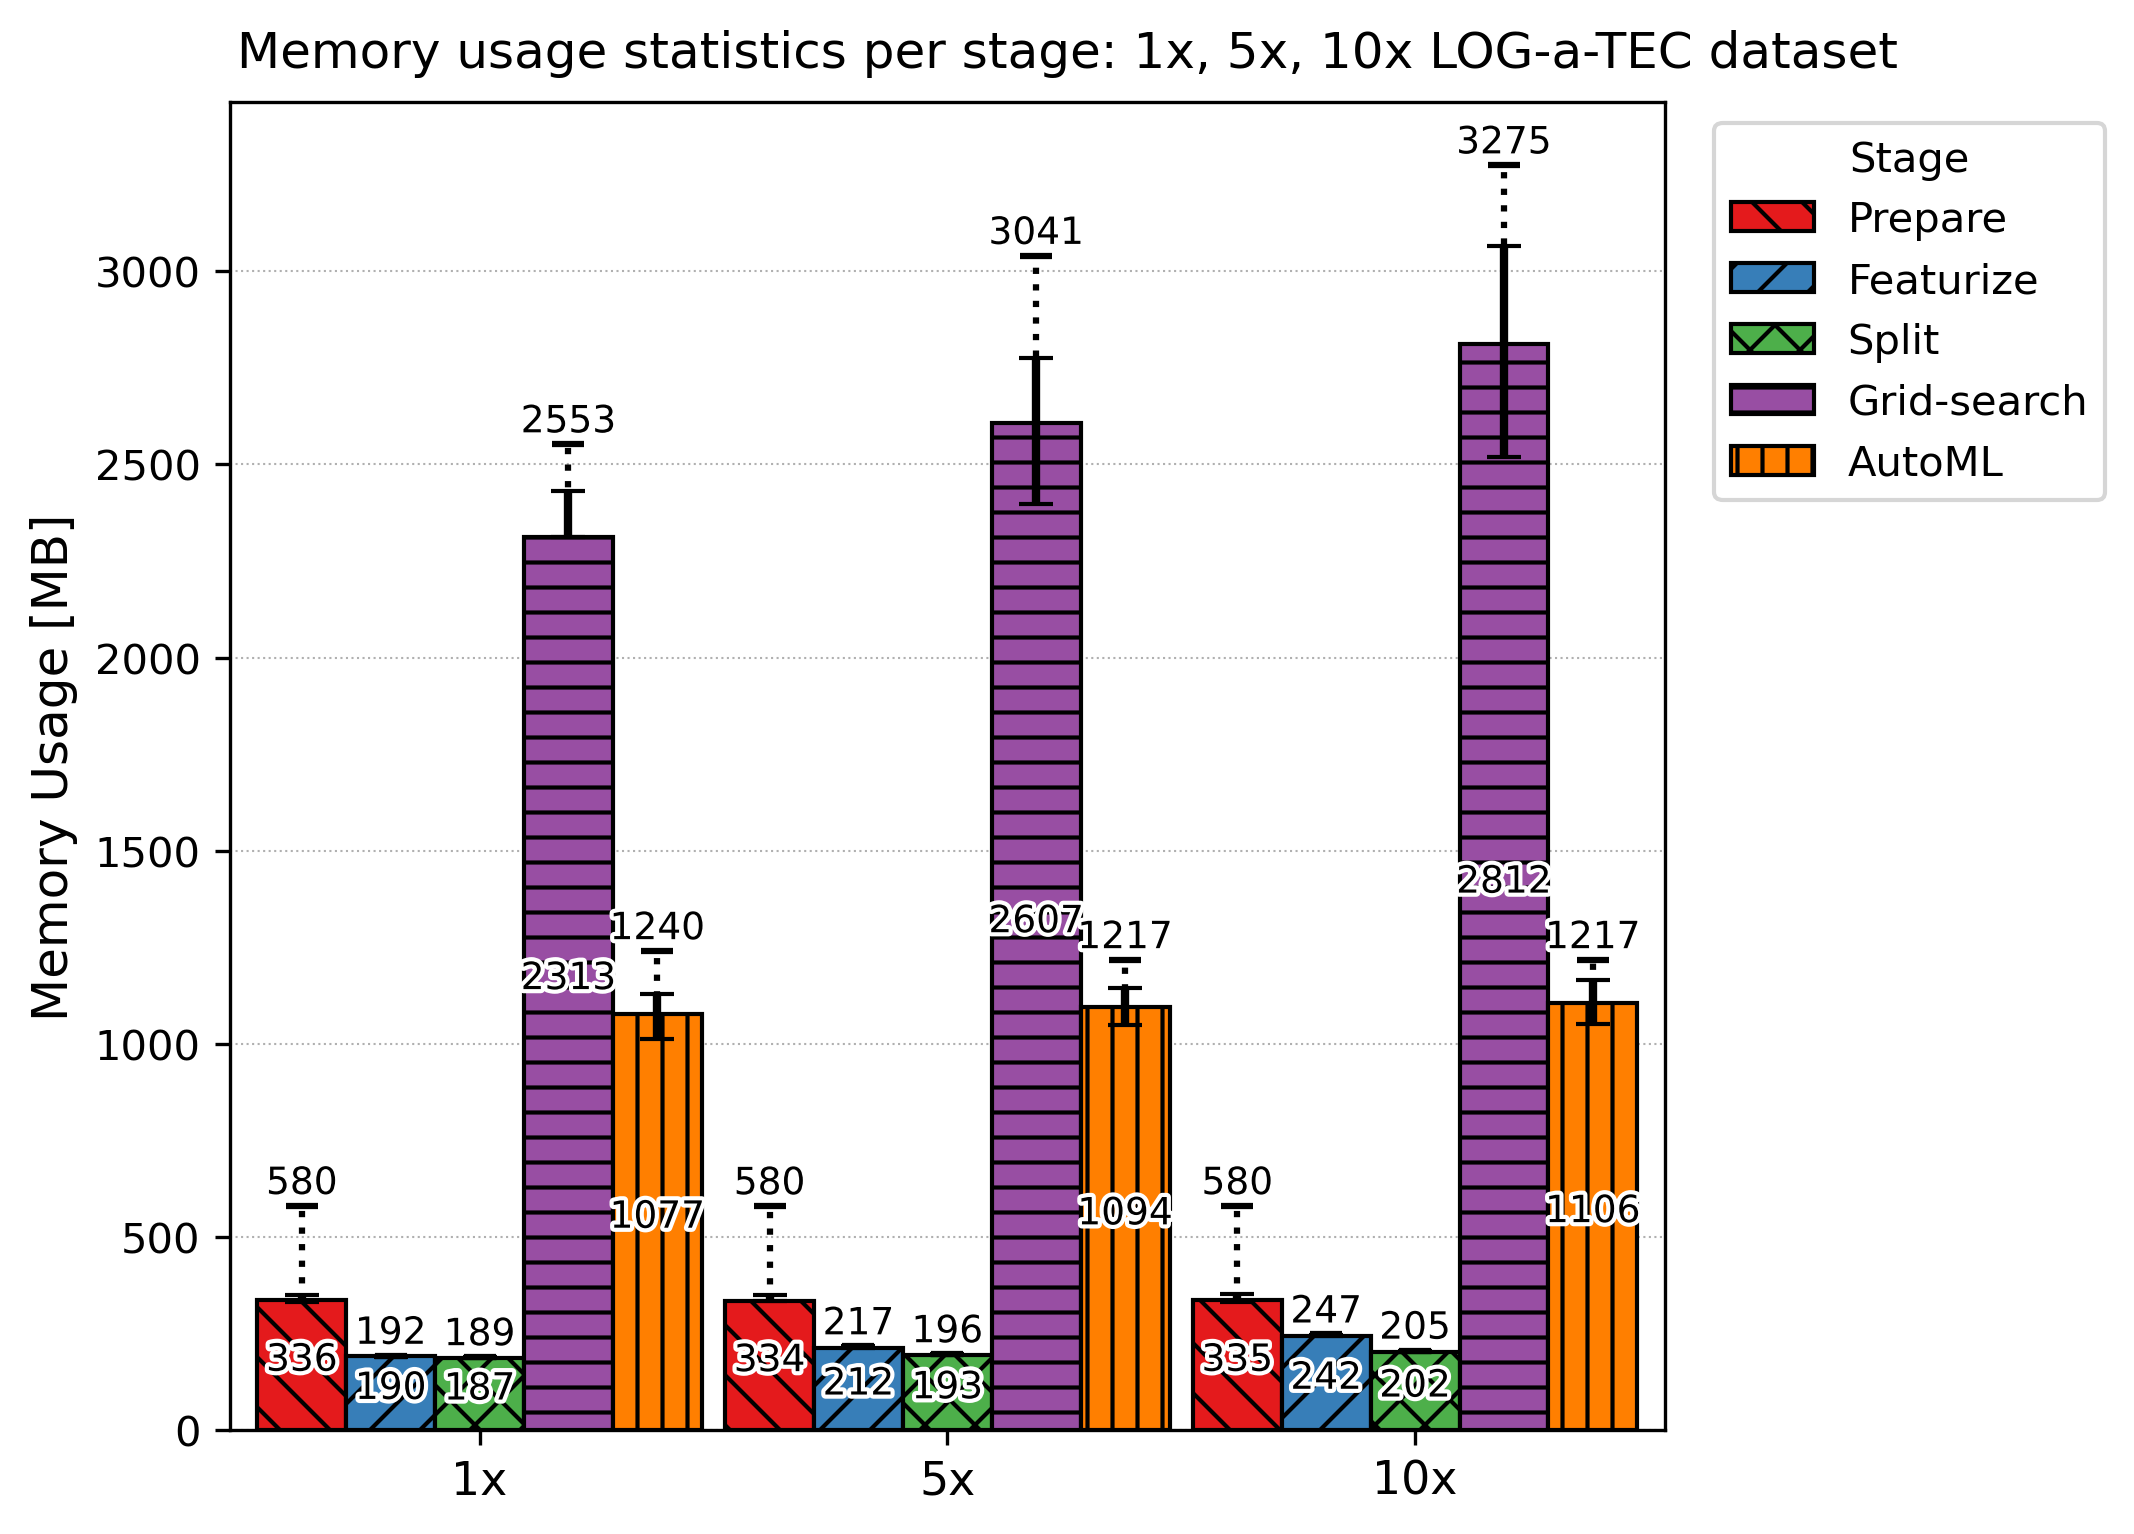

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch 
import matplotlib.colors as mcolors
import colorsys


# -------- parameters ----------------------------------------------------------
stats   = ['max', 'mean', 'min']
hatches = {'prepare': '\\\\', 'featurize': '//', 'split': 'xx', 'gridsearch':"--", "automl":"||"}
base_cmap = plt.get_cmap("Set1")          
colours   = base_cmap(np.linspace(0, 1, 9)) #base_cmap(np.linspace(0, 1, len(stages)))

#base_cmap = plt.get_cmap("gist_rainbow")        
#colours   = base_cmap(np.linspace(0, 1, len(stages)))

# -------- geometry: how wide each bar is --------------------------------------
n_impl  = len(sub_dirs)    
n_stage = len(stages)
n_stat  = len(stats)

group_width = 0.95
bar_width   = group_width / (n_stage)
alphas      = {'max': 1.0, 'mean': 1.0, 'min': 1.0} 
shade       = {'max': 0.6, 'mean': 0.3, 'min': 0.0}

# -------- create figure -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout = True, dpi=300)

# -------- draw every bar ------------------------------------------------------
for impl_i, (impl_name, df) in enumerate(zip(sub_dirs, mem_stats_dfs)):
    base_x = impl_i
    for stage_i, stage in enumerate(stages):
        x_pos = base_x - group_width/2 + stage_i*bar_width + bar_width/2
        
        m  = df.loc["mean", stage]
        mx = df.loc["max", stage]
        q1 = df.loc["q1", stage]
        q3 = df.loc["q3", stage]

        bar_col = colours[stage_i]

        bar = ax.bar(
            x_pos,
            m,
            width=bar_width,
            color=bar_col,
            hatch=hatches[stage],
            edgecolor='black'
        )
        texts = ax.bar_label(bar, padding=1, label_type='center', fmt='%d', fontsize=9)
        for t in texts:
            t.set_path_effects([
                pe.Stroke(linewidth=2, foreground='white'),  # outline
                pe.Normal()                                  # fill (uses the current text color)
            ])

        yerr = [[max(m - q1, 0)], [max(q3 - m, 0)]]
        ax.errorbar(x_pos, m, yerr=yerr,
                    fmt='none', ecolor='black', capsize=4, linewidth=2)

        ax.vlines(x_pos, m, mx, linestyles=':', colors='black', linewidth=1.5,
          zorder=3, label="_nolegend_")

        ax.scatter(x_pos, mx, marker='_', s=60, c="black", zorder=4, label="_nolegend_")
        txt = ax.text(x_pos, mx + 10, f"{mx:.0f}", ha='center', va='bottom', fontsize=9, color='black')
        txt.set_path_effects([
            pe.Stroke(linewidth=2, foreground='white'),
            pe.Normal()
        ])

#        for stat in stats:
#            height = df.loc[stat, stage]
#
#            bar_col = lighten(colours[stage_i], shade[stat])
#            ax.bar(
#                x_pos,
#                height,
#                width=bar_width,
#                color=bar_col,
#                edgecolor='black',
#                hatch=hatches[stat],
#                alpha=alphas[stat],
#            )

# -------- x-axis, grid, labels -----------------------------------------------
ax.set_xticks(range(n_impl))
ax.set_xticklabels([sub_dir.capitalize() for sub_dir in sub_dirs], fontsize=11)
ax.set_ylabel("Memory Usage [MB]", fontsize=12)
ax.margins(x=0.02)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', linewidth=0.5)

# -------- legends -------------------------------------------------------------
# 1 legend for stages (colour)
stage_handles = [
    Patch(facecolor=colours[i], edgecolor='black', label=stage_names[i], hatch=hatches[stage])
    for i, stage in enumerate(stages)
]

## 2 legend for statistics (hatch)
#stat_handles = [
#    Patch(facecolor='white', edgecolor='black', hatch=hatches[s], label=s.capitalize())
#    for s in stats
#]

#first = ax.legend(handles=stat_handles, title="Statistic", loc='upper left', bbox_to_anchor=(1.02, 0.55))
#ax.add_artist(first)   
ax.legend(handles=stage_handles, title="Stage", loc='upper left', bbox_to_anchor=(1.02, 1.0))
fig.suptitle("Memory usage statistics per stage: 1x, 5x, 10x LOG-a-TEC dataset")

fig.canvas.draw() 

plt.savefig("DSSC_MemUsageGraph.png", dpi=fig.dpi)
plt.show()  # uncomment to display

In [47]:
# CPU Time
import joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt
cpu_secs = {sub_dir:{} for sub_dir in sub_dirs}
for sub_dir in sub_dirs:

    for stage in stages:
        df = dfs[sub_dir][stage]
        cpu_secs[sub_dir][stage] = {
            "CPU_time": np.trapz(df["cpu_cores"].values, df["elapsed"].values),
            "wall_time"     : df["t"].iloc[-1]
        }
    cpu_secs[sub_dir] = pd.DataFrame(cpu_secs[sub_dir])

for idx, sub_dir in enumerate(sub_dirs):
    print(sub_dir)
    print(cpu_secs[sub_dir])
    print()

1x
             prepare  featurize     split   gridsearch       automl
CPU_time   19.220644   0.425433  0.281559  3137.022128  1066.809200
wall_time  19.401974   0.501984  0.404710   664.373629   662.704476

5x
             prepare  featurize     split    gridsearch       automl
CPU_time   18.428518   2.541086  3.287295  12719.991695  3402.705390
wall_time  18.602503   2.701486  2.902766   2631.300360  1757.505886

10x
            prepare  featurize     split    gridsearch       automl
CPU_time   21.72691   5.430585  6.088408  21248.072950  4430.014117
wall_time  21.90198   5.601715  5.905476   4412.529766  2268.405381



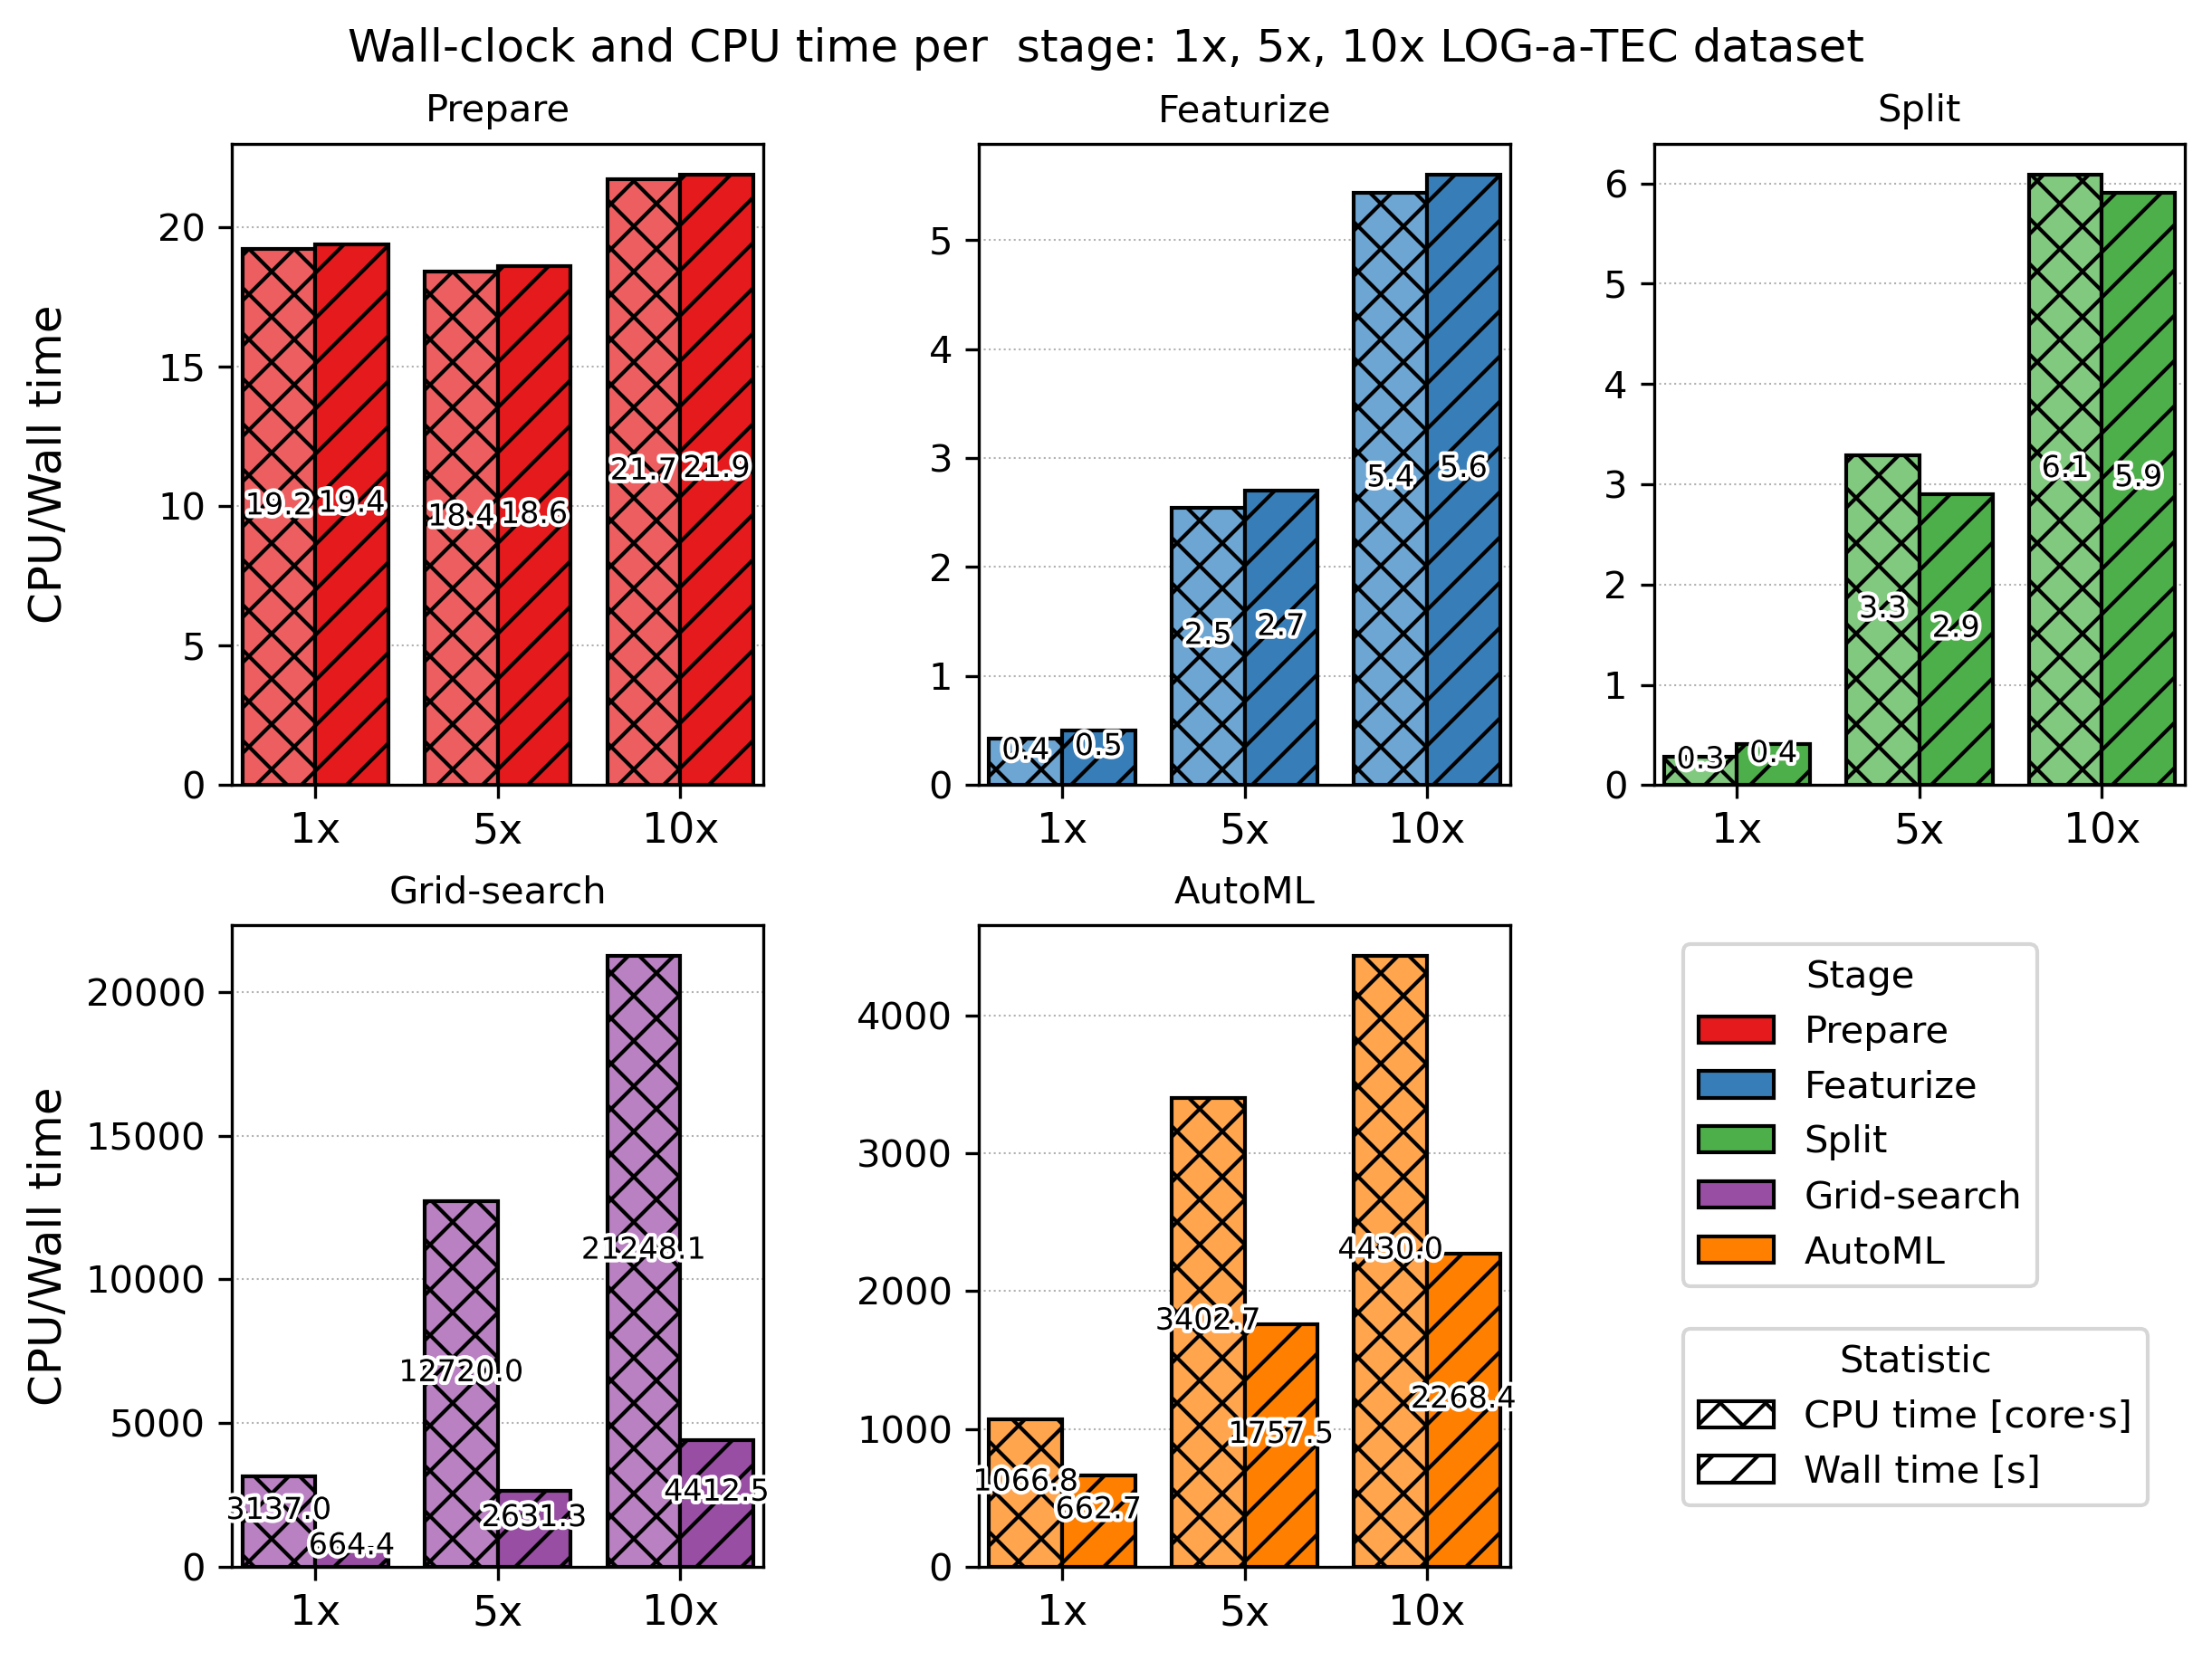

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 
import matplotlib.colors as mcolors
import colorsys

def lighten(color, amount):
    """
    Lighten *color* by blending it with white.
    amount = 0   -> original colour
    amount = 1   -> white
    """
    try:
        c = mcolors.to_rgb(color)
    except ValueError:          # named colour
        c = mcolors.to_rgb(mcolors.CSS4_COLORS[color])
    h, l, s = colorsys.rgb_to_hls(*c)
    l = 1 - (1 - l) * (1 - amount)   # push l toward 1
    return colorsys.hls_to_rgb(h, l, s)


# -------- parameters ----------------------------------------------------------
stats   = ['CPU_time', 'wall_time']
hatches = {'CPU_time': 'xx', 'wall_time': '//'}
base_cmap = plt.get_cmap("Set1")          
colours   = base_cmap(np.linspace(0, 1, 9)) #base_cmap(np.linspace(0, 1, len(stages)))

#base_cmap = plt.get_cmap("gist_rainbow")        
#colours   = base_cmap(np.linspace(0, 1, len(stages)))

# -------- geometry: how wide each bar is --------------------------------------
n_impl  = len(sub_dirs)    
n_stage = len(stages)
n_stat  = len(stats)

group_width = 0.8
bar_width   = group_width / (n_stat)
alphas      = {'CPU_time': 1.0, 'wall_time': 1.0} 
shade       = {'CPU_time': 0.3, 'wall_time': 0.0}


fig, axes = plt.subplots(2, 3, figsize=(8, 6), constrained_layout=True, dpi=300)
axes = axes.flatten()
# -------- draw every bar ------------------------------------------------------
for stage_i, (stage, ax) in enumerate(zip(stages, axes[:-1])):
    # -------- create figure -------------------------------------------------------
    for impl_i, (impl_name, df) in enumerate(zip(sub_dirs, cpu_secs.values())):
        for stat_i, stat in enumerate(stats):
            base_x = impl_i
            #x_pos = base_x - group_width/2 + stage_i*bar_width + bar_width/2
            x_pos = base_x - group_width/2 + stat_i*bar_width + bar_width/2

            height = df.loc[stat, stage]

            bar_col = lighten(colours[stage_i], shade[stat])
            bar = ax.bar(
                x_pos,
                height,
                width=bar_width,
                color=bar_col,
                edgecolor='black',
                hatch=hatches[stat],
                alpha=alphas[stat],
            )
            texts = ax.bar_label(bar, padding=3, label_type='center', fmt='%.1f', fontsize=8)
            for t in texts:
                t.set_path_effects([
                    pe.Stroke(linewidth=2, foreground='white'),  # outline
                    pe.Normal()                                  # fill (uses the current text color)
                ])

    # -------- x-axis, grid, labels -----------------------------------------------
    ax.set_xticks(range(n_impl))
    ax.set_xticklabels([sub_dir.capitalize() for sub_dir in sub_dirs], fontsize=11)
    ax.margins(x=0.02)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle=':', linewidth=0.5)

# -------- legends -------------------------------------------------------------
ax = axes[-1]
ax.axis("off") 

# 1 legend for stages (colour)
stage_handles = [
    Patch(facecolor=colours[i], edgecolor='black', label=stage_names[i])
    for i, stage in enumerate(stages)
]

units = {"CPU_time": " [core·s]", "wall_time":" [s]"}
stat_display = {"CPU_time": "CPU time", "wall_time":"Wall time"}
# 2 legend for statistics (hatch)
stat_handles = [
    Patch(facecolor='white', edgecolor='black', hatch=hatches[s], label=stat_display[s]+units[s])
    for s in stats
]

first = ax.legend(handles=stage_handles, title="Stage", loc='upper left', bbox_to_anchor=(0.02, 1.0))
ax.add_artist(first)                              # keep first legend when adding second
ax.legend(handles=stat_handles, title="Statistic", loc='upper left', bbox_to_anchor=(0.02, 0.4))

# -------- titles & ylabel -----------------------------------------------------
for stage_i, (ax, stage) in enumerate(zip(axes[:-1], stages)):
    ax.set_title(stage_names[stage_i], fontsize=10)
    if stage_i%3 == 0:
        ax.set_ylabel(f"CPU/Wall time", fontsize=12)

fig.align_ylabels()
fig.set_constrained_layout_pads( 
        w_pad=2/72, h_pad=3/72,
        wspace=0.12, hspace=0.02)

fig.suptitle("Wall-clock and CPU time per  stage: 1x, 5x, 10x LOG-a-TEC dataset")

#fig.subplots_adjust(right=0.8, left=0.08, top=1, bottom=0)
fig.canvas.draw()                          

#bbox = fig.get_tightbbox(fig.canvas.get_renderer())
#new_w, new_h = bbox.width, bbox.height
#
#fig.set_size_inches(new_w, new_h, forward=True) 
plt.savefig("DSSC_CPUWall_time.png", dpi=fig.dpi) #,bbox_inches="tight", bbox_extra_artists=fig.get_children()
plt.show()

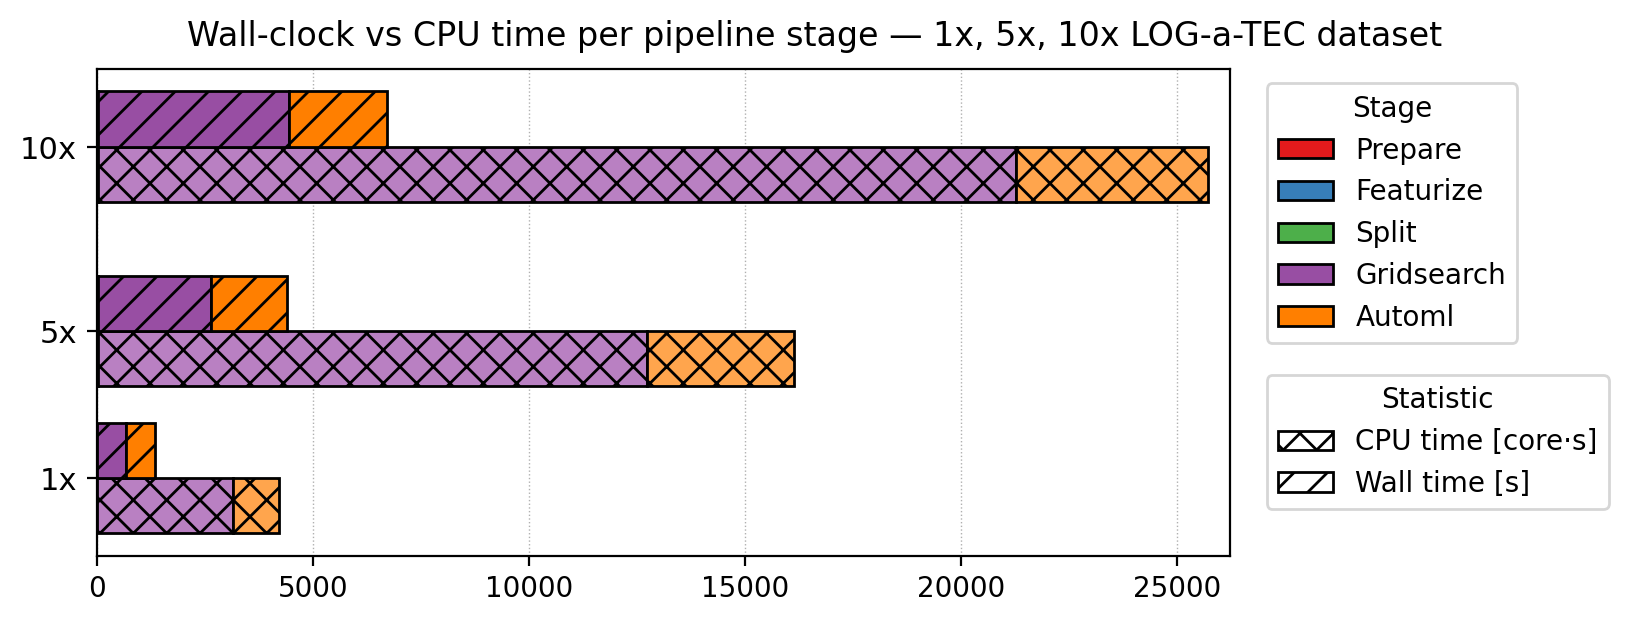

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 
import matplotlib.colors as mcolors
import colorsys

def lighten(color, amount):
    """
    Lighten *color* by blending it with white.
    amount = 0   -> original colour
    amount = 1   -> white
    """
    try:
        c = mcolors.to_rgb(color)
    except ValueError:          # named colour
        c = mcolors.to_rgb(mcolors.CSS4_COLORS[color])
    h, l, s = colorsys.rgb_to_hls(*c)
    l = 1 - (1 - l) * (1 - amount)   # push l toward 1
    return colorsys.hls_to_rgb(h, l, s)


# -------- parameters ----------------------------------------------------------
stats   = ['CPU_time', 'wall_time']
hatches = {'CPU_time': 'xx', 'wall_time': '//'}
base_cmap = plt.get_cmap("Set1")          
colours   = base_cmap(np.linspace(0, 1, 9)) #base_cmap(np.linspace(0, 1, len(stages)))

#base_cmap = plt.get_cmap("gist_rainbow")        
#colours   = base_cmap(np.linspace(0, 1, len(stages)))

# -------- geometry: how wide each bar is --------------------------------------
n_impl  = len(sub_dirs)    
n_stage = len(stages)
n_stat  = len(stats)

group_height = 3.0
bar_height   = group_height / (n_stat)
alphas      = {'CPU_time': 1.0, 'wall_time': 1.0} 
shade       = {'CPU_time': 0.3, 'wall_time': 0.0}
scale = {"1x": 1, "5x": 5, "10x": 10}

fig, ax = plt.subplots(1,1, figsize=(8, 3), constrained_layout=True, dpi=200)
# -------- draw every bar ------------------------------------------------------
for impl_i, (impl_name, df) in enumerate(zip(sub_dirs, cpu_secs.values())):
    for stat_i, stat in enumerate(stats):
        left = 0
        for stage_i, stage in enumerate(stages):
            base_y = scale[impl_name]
            #x_pos = base_x - group_width/2 + stage_i*bar_width + bar_width/2
            y_pos = base_y - bar_height  + stat_i*bar_height 

            width = df.loc[stat, stage]

            bar_col = lighten(colours[stage_i], shade[stat])
            ax.barh(
                y = y_pos,
                width=width,
                left=left,
                height=bar_height,
                color=bar_col,
                edgecolor='black',
                hatch=hatches[stat],
                alpha=alphas[stat],
                align="edge"
            )

            left += width

# -------- x-axis, grid, labels -----------------------------------------------
ax.set_yticks(list(scale.values()))
ax.set_yticklabels([sub_dir.capitalize() for sub_dir in sub_dirs], fontsize=11)
ax.margins(x=0.02)
ax.set_axisbelow(True)
ax.grid(axis='x', linestyle=':', linewidth=0.5)

# -------- legends -------------------------------------------------------------
#for ax in axes[:,-1]:
    #ax.axis("off") 


# 1 legend for stages (colour)
stage_handles = [
    Patch(facecolor=colours[i], edgecolor='black', label=stage.capitalize())
    for i, stage in enumerate(stages)
]

units = {"CPU_time": " [core·s]", "wall_time":" [s]"}
stat_display = {"CPU_time": "CPU time", "wall_time":"Wall time"}
# 2 legend for statistics (hatch)
stat_handles = [
    Patch(facecolor='white', edgecolor='black', hatch=hatches[s], label=stat_display[s]+units[s])
    for s in stats
]

first = ax.legend(handles=stage_handles, title="Stage", loc='upper left', bbox_to_anchor=(1.02, 1.0))
ax.add_artist(first)                              # keep first legend when adding second
ax.legend(handles=stat_handles, title="Statistic", loc='upper left', bbox_to_anchor=(1.02, 0.4))

# -------- titles & ylabel -----------------------------------------------------
for stage_i, (ax, stat) in enumerate(zip(axes, stats)):
    ax.set_title(stat_display[stat], fontsize=12)
    #ax.set_xlabel(stat_display[stat], fontsize=12)

fig.align_ylabels()
fig.set_constrained_layout_pads( 
        w_pad=2/72, h_pad=3/72,
        wspace=0.12, hspace=0.02)

fig.suptitle("Wall-clock vs CPU time per pipeline stage — 1x, 5x, 10x LOG-a-TEC dataset")

#fig.subplots_adjust(right=0.8, left=0.08, top=1, bottom=0)
fig.canvas.draw()                          

#bbox = fig.get_tightbbox(fig.canvas.get_renderer())
#new_w, new_h = bbox.width, bbox.height
#
#fig.set_size_inches(new_w, new_h, forward=True) 
plt.savefig("DSSC_barh-CPUWall_time.png", dpi=fig.dpi) #,bbox_inches="tight", bbox_extra_artists=fig.get_children()
plt.show()

In [81]:
time = {sub_dir: {} for sub_dir in sub_dirs}
for sub_dir in sub_dirs:
    for stat in stats:
        time[sub_dir][stat] = cpu_secs[sub_dir].loc[stat].sum()

In [82]:
df = pd.DataFrame(time)
df.columns = df.columns.str.capitalize()
df.index = df.index.str.replace("_", " ").str.capitalize()

print(df.to_latex(float_format="%.0f"))
df

\begin{tabular}{lrrr}
\toprule
 & 1x & 5x & 10x \\
\midrule
Cpu time & 4224 & 16147 & 25711 \\
Wall time & 1347 & 4413 & 6714 \\
\bottomrule
\end{tabular}



,1x,5x,10x
Cpu time,4223.758965,16146.953985,25711.332969
Wall time,1347.386772,4413.013001,6714.344319


In [83]:
dfm = df.div(df[sub_dirs[0]], axis=0)
dfm

,1x,5x,10x
Cpu time,1.0,3.822887,6.087311
Wall time,1.0,3.275238,4.983235


KeyError: 'CPU_time'

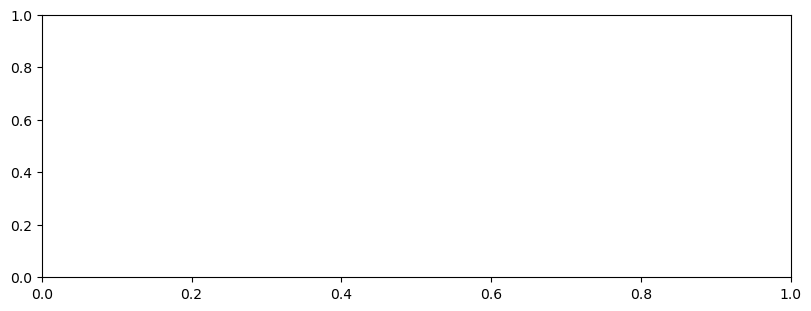

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 
import matplotlib.colors as mcolors
import colorsys

def lighten(color, amount):
    """
    Lighten *color* by blending it with white.
    amount = 0   -> original colour
    amount = 1   -> white
    """
    try:
        c = mcolors.to_rgb(color)
    except ValueError:          # named colour
        c = mcolors.to_rgb(mcolors.CSS4_COLORS[color])
    h, l, s = colorsys.rgb_to_hls(*c)
    l = 1 - (1 - l) * (1 - amount)   # push l toward 1
    return colorsys.hls_to_rgb(h, l, s)


# -------- parameters ----------------------------------------------------------
stats   = ['CPU_time', 'wall_time']
hatches = {'CPU_time': 'xx', 'wall_time': '//'}
base_cmap = plt.get_cmap("Set1")          
colours   = base_cmap(np.linspace(0, 1, 9)) #base_cmap(np.linspace(0, 1, len(stages)))

#base_cmap = plt.get_cmap("gist_rainbow")        
#colours   = base_cmap(np.linspace(0, 1, len(stages)))

# -------- geometry: how wide each bar is --------------------------------------
n_impl  = len(sub_dirs)    
n_stage = len(stages)
n_stat  = len(stats)

group_width = 0.8
bar_height   = group_width / (n_stat)
alphas      = {'CPU_time': 1.0, 'wall_time': 1.0} 
shade       = {'CPU_time': 0.3, 'wall_time': 0.0}


fig, ax = plt.subplots(1,1, figsize=(8, 3), constrained_layout=True)
# -------- draw every bar ------------------------------------------------------
for impl_i, impl_name in enumerate(sub_dirs):
    for stat_i, stat in enumerate(stats):
        base_y = impl_i
        #x_pos = base_x - group_width/2 + stage_i*bar_width + bar_width/2
        y_pos = base_y - group_width/2 + stat_i*bar_width + bar_width/2

        width = dfm.loc[stat, impl_name]

        bar_col = lighten(colours[impl_i], shade[stat])
        ax.barh(
            y = y_pos,
            width=width,
            height=bar_height,
            color=bar_col,
            edgecolor='black',
            hatch=hatches[stat],
            alpha=alphas[stat],
        )


        # -------- x-axis, grid, labels -----------------------------------------------
        ax.set_yticks(range(n_impl))
        ax.set_yticklabels([sub_dir.capitalize() for sub_dir in sub_dirs], fontsize=11)
        ax.margins(x=0.02)
        ax.set_axisbelow(True)
        ax.grid(axis='x', linestyle=':', linewidth=0.5)

# -------- legends -------------------------------------------------------------
#for ax in axes[:,-1]:
    #ax.axis("off") 


# 1 legend for stages (colour)
impl_handles = [
    Patch(facecolor=colours[i], edgecolor='black', label=impl_name.capitalize())
    for i, impl_name in enumerate(sub_dirs)
]

units = {"CPU_time": " [core·s]", "wall_time":" [s]"}
stat_display = {"CPU_time": "CPU time", "wall_time":"Wall time"}
# 2 legend for statistics (hatch)
stat_handles = [
    Patch(facecolor='white', edgecolor='black', hatch=hatches[s], label=stat_display[s]+units[s])
    for s in stats
]

first = ax.legend(handles=impl_handles, title="Stage", loc='upper left', bbox_to_anchor=(1.02, 1.0))
ax.add_artist(first)                              # keep first legend when adding second
ax.legend(handles=stat_handles, title="Statistic", loc='upper left', bbox_to_anchor=(1.02, 0.4))

# -------- titles & ylabel -----------------------------------------------------
for stage_i, (ax, stat) in enumerate(zip(axes, stats)):
    ax.set_title(stat_display[stat], fontsize=12)
    #ax.set_xlabel(stat_display[stat], fontsize=12)

fig.align_ylabels()
fig.set_constrained_layout_pads( 
        w_pad=2/72, h_pad=3/72,
        wspace=0.12, hspace=0.02)

fig.suptitle("Wall-clock vs CPU time per pipeline stage — 1x, 5x, 10x LOG-a-TEC dataset")

#fig.subplots_adjust(right=0.8, left=0.08, top=1, bottom=0)
fig.canvas.draw()                          

#bbox = fig.get_tightbbox(fig.canvas.get_renderer())
#new_w, new_h = bbox.width, bbox.height
#
#fig.set_size_inches(new_w, new_h, forward=True) 
plt.savefig("DSSC_barh-CPUWall_time.png", dpi=fig.dpi) #,bbox_inches="tight", bbox_extra_artists=fig.get_children()
plt.show()